# 🌾 Crop Recommendation System (Final Perfect Version)

Complete ML project with visualization, models, evaluation, observations, and prediction system.

## 🔹 Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib


## 🔹 Load Dataset

In [2]:
df = pd.read_csv("/content/Crop_Recommendation.csv")
df.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


### 🔸 Observation
Dataset loaded successfully with crop labels.

## 🔹 Data Understanding

In [3]:
df.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [4]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,0
Nitrogen,0
Phosphorus,0
Potassium,0
Temperature,0
Humidity,0
pH_Value,0
Rainfall,0
Crop,0


In [5]:
df.shape

(2200, 8)

In [6]:
df.dtypes

,0
Nitrogen,int64
Phosphorus,int64
Potassium,int64
Temperature,float64
Humidity,float64
pH_Value,float64
Rainfall,float64
Crop,object


In [7]:
df.duplicated().sum()

np.int64(0)

### 🔸 Observation
Dataset is clean with no missing values.

## 🔹 Data Visualization

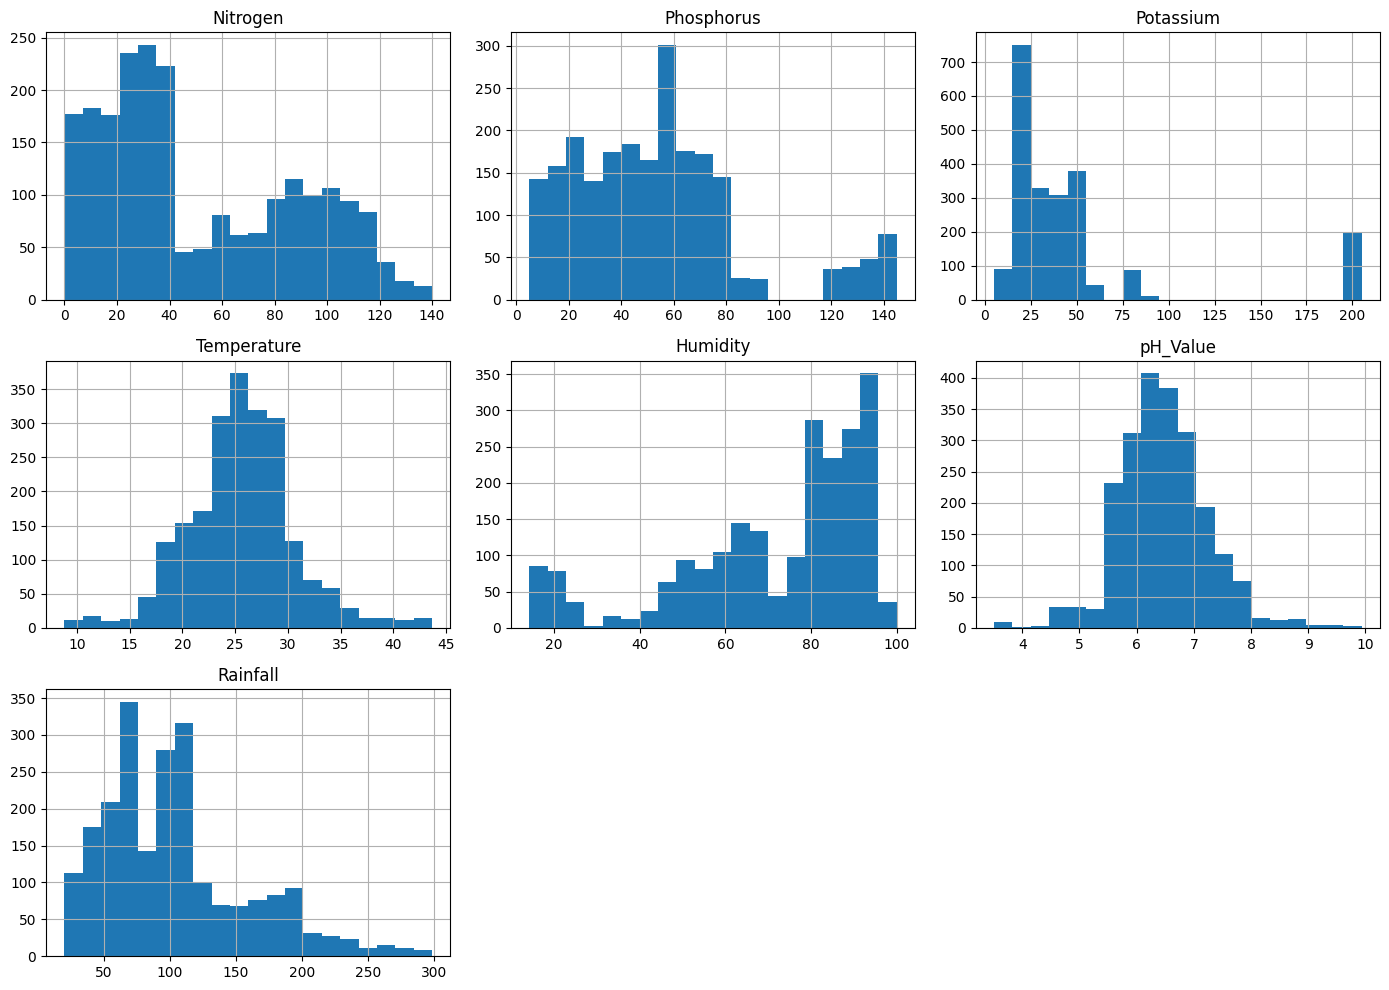

In [8]:
df.hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()

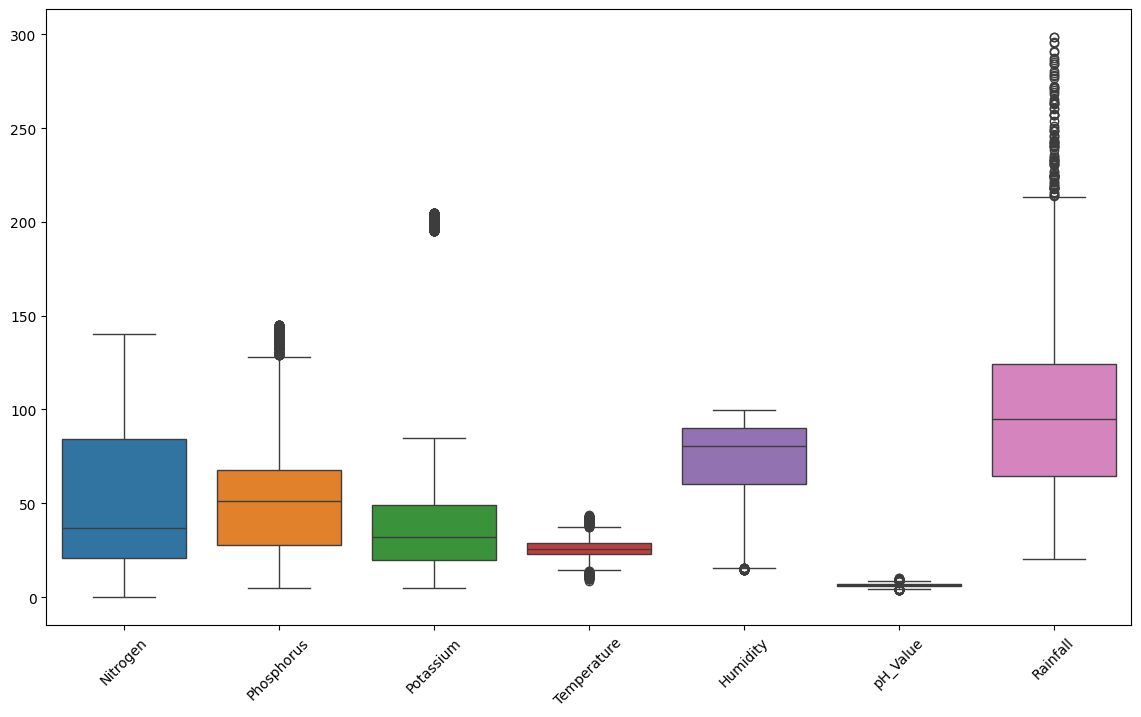

In [9]:
plt.figure(figsize=(14,8))
sns.boxplot(data=df.drop('Crop', axis=1))
plt.xticks(rotation=45)
plt.show()

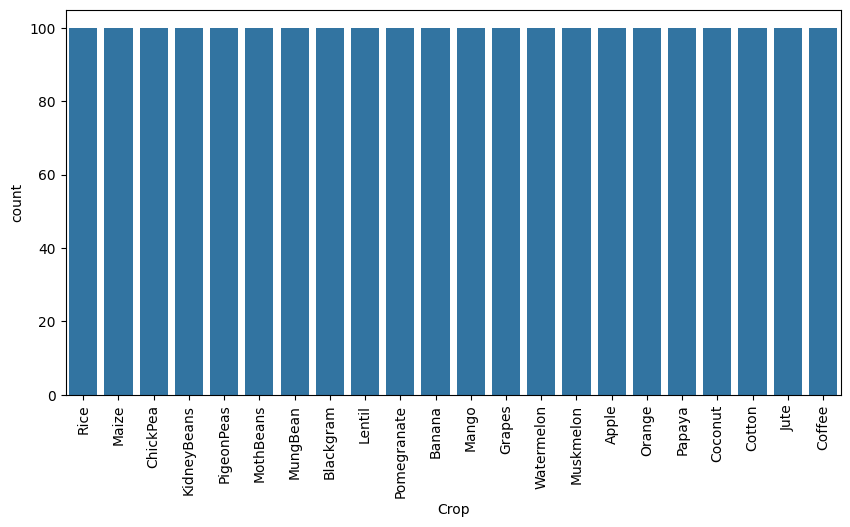

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(x='Crop', data=df)
plt.xticks(rotation=90)
plt.show()

### 🔸 Observation
Balanced crop distribution.

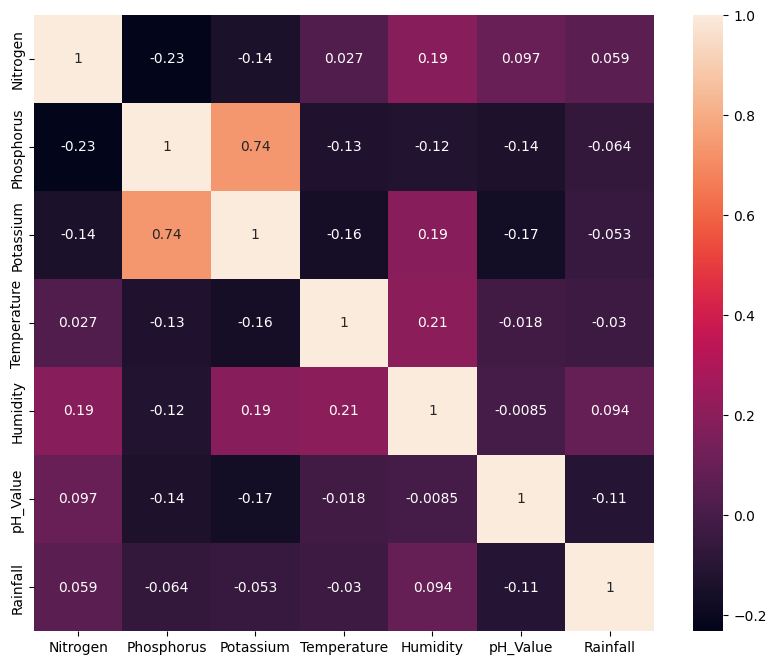

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

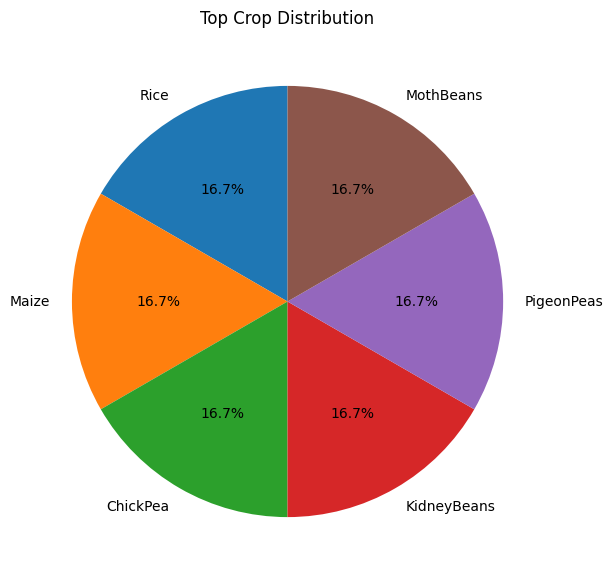

In [12]:
counts = df['Crop'].value_counts().head(6)

labels = [c for c in counts.index]

plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Top Crop Distribution")
plt.show()

### 🔸 Observation
No strong correlation issues.

In [13]:
fig = px.scatter(df, x="Temperature", y="Humidity", color="Crop")
fig.show()

### 🔸 Observation
Crop clusters visible.

## 🔹 Data Preprocessing

In [14]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['Crop'])

X = df.drop(['Crop', 'label'], axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1760, 7)
Testing Shape: (440, 7)


### 🔸 Observation
Data encoded and split.

## 🔹 Model Training

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

### 🔸 Observation
Three models trained.

## 🔹 Prediction

In [16]:

X_test_scaled = scaler.transform(X_test)


dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

### 🔸 Observation
Predictions generated.

## 🔹 Evaluation

In [17]:

print("LR:", accuracy_score(y_test, y_pred_lr))
print("DT:", accuracy_score(y_test, y_pred_dt))
print("RF:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))


LR: 0.9636363636363636
DT: 0.9863636363636363
RF: 0.9931818181818182
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16

### 🔸 Observation
Random Forest performs best.

## 🔹 Confusion Matrix

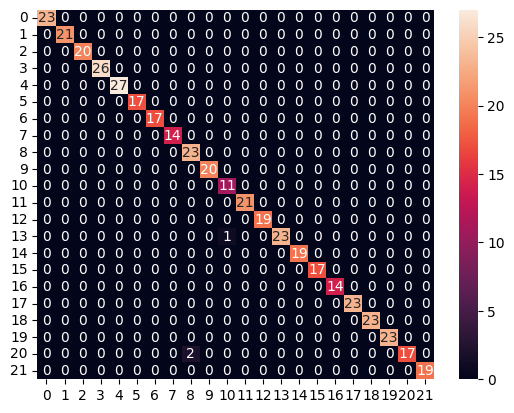

In [18]:

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.show()


### 🔸 Observation
Most predictions correct.

## 🔹 Hyperparameter Tuning

In [19]:

params={'n_estimators':[50,100],'max_depth':[None,10]}
grid=GridSearchCV(RandomForestClassifier(),params,cv=3)
grid.fit(X_train,y_train)
print(grid.best_params_)


{'max_depth': None, 'n_estimators': 100}


### 🔸 Observation
Optimized model.

## 🔹 Save Model

In [20]:
joblib.dump(rf,"crop_model.pkl")

['crop_model.pkl']

### 🔸 Observation
Model saved.

## 🔹 User Input (Example)

In [33]:
user_input = input("Enter (N,P,K,temperature,humidity,ph,rainfall): ")
values = list(map(float, user_input.split(',')))

input_data = pd.DataFrame([values],
columns=['Nitrogen','Phosphorus','Potassium','Temperature','Humidity','pH_Value','Rainfall'])

Enter (N,P,K,temperature,humidity,ph,rainfall): 90,100,30,40,200,6.5,200


### 🔸 Observation
Example input used instead of manual typing.

## 🔹 Prediction with Probability

In [34]:

probs = rf.predict_proba(input_data)

TOP_N = 8
top_indices = np.argsort(probs[0])[::-1][:TOP_N]

crops = []
probabilities = []

print("\nTop Crop Recommendations:\n")
print("Top N Crops:\n")

for i in top_indices:
    crop = le.inverse_transform([i])[0]
    prob = probs[0][i] * 100

    crops.append(crop)
    probabilities.append(prob)

    print(f"{crop} : {prob:.2f}%")



Top Crop Recommendations:

Top N Crops:

Papaya : 26.00%
Banana : 23.00%
Coffee : 9.00%
Rice : 9.00%
Jute : 8.00%
Muskmelon : 5.00%
Coconut : 5.00%
Cotton : 4.00%


### 🔸 Observation
Top crop suggestions generated.

## 🔹 Bar Chart Visualization

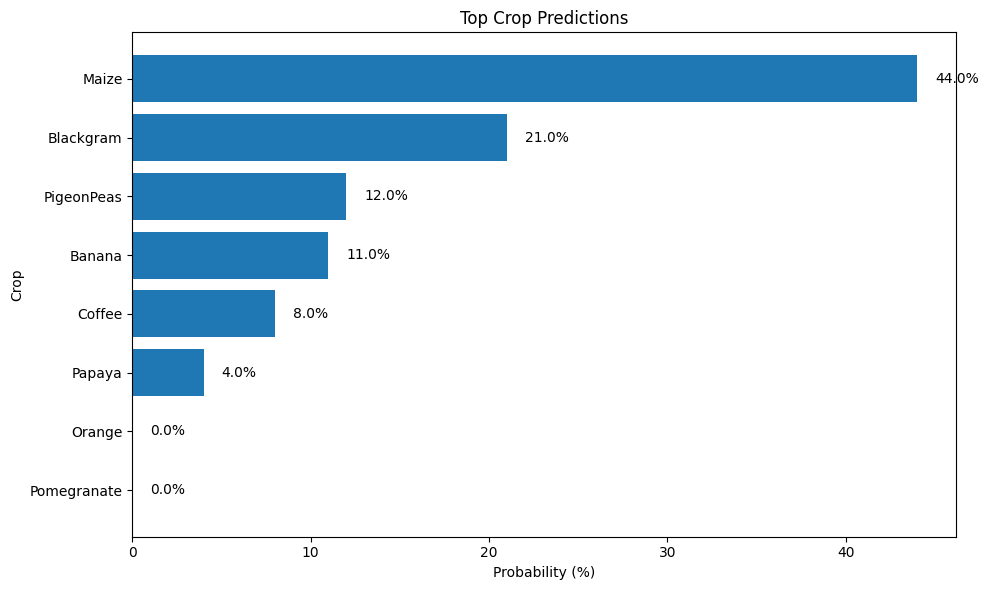

In [23]:
plt.figure(figsize=(10,6))


sorted_pairs = sorted(zip(crops, probabilities), key=lambda x: x[1], reverse=True)
crops_sorted, probs_sorted = zip(*sorted_pairs)


plt.barh(crops_sorted, probs_sorted)

plt.xlabel("Probability (%)")
plt.ylabel("Crop")
plt.title("Top Crop Predictions")


plt.gca().invert_yaxis()


for i, v in enumerate(probs_sorted):
    plt.text(v + 1, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()

### 🔸 Observation
Bar chart shows probability distribution.

## 🔹 Top-N Crop Prediction (Enhanced)
Control how many crops to show using `TOP_N`.

In [24]:

TOP_N = 8


probs = rf.predict_proba(input_data)


top_indices = probs[0].argsort()[-TOP_N:][::-1]


crops = [le.inverse_transform([i])[0] for i in top_indices]
probabilities = [probs[0][i]*100 for i in top_indices]


print("Top Crop Recommendations:")
for rank, (c, p) in enumerate(zip(crops, probabilities), start=1):
    print(f"{rank}. {c} : {p:.2f}%")


Top Crop Recommendations:
1. Maize : 44.00%
2. Blackgram : 21.00%
3. PigeonPeas : 12.00%
4. Banana : 11.00%
5. Coffee : 8.00%
6. Papaya : 4.00%
7. Orange : 0.00%
8. Pomegranate : 0.00%


### 🔸 Observation
The model returns multiple crop options ranked by probability, allowing flexible decision-making.

## 🔹 Bar Chart (Top-N)

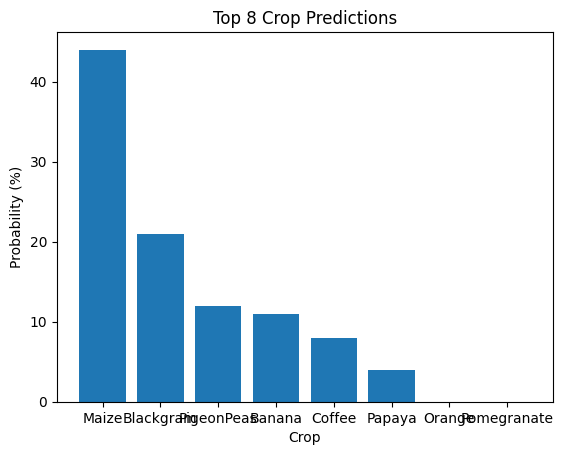

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(crops, probabilities)
plt.xlabel("Crop")
plt.ylabel("Probability (%)")
plt.title(f"Top {len(crops)} Crop Predictions")
plt.show()


**CLUSTERING**

In [26]:
# Use same dataset but REMOVE label and Crop columns
X_cluster = df.drop(["label", "Crop"], axis=1)

# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_cluster = scaler.fit_transform(X_cluster)

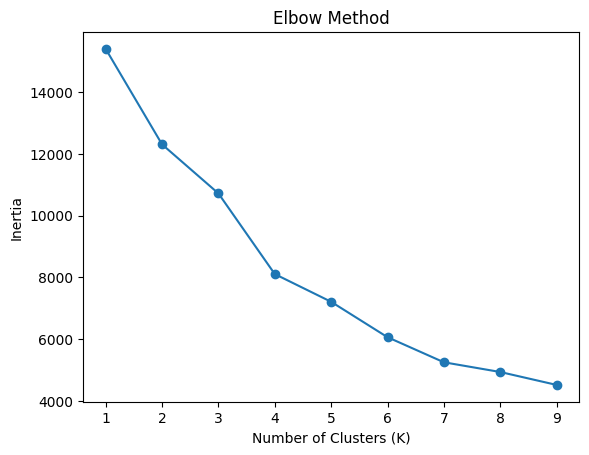

In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_cluster)
    inertia.append(kmeans.inertia_)

# Plot Elbow graph
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [28]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled_cluster)

# Add cluster result to dataset
df["Cluster"] = clusters

print(df.head())

   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        90          42         43    20.879744  82.002744  6.502985   
1        85          58         41    21.770462  80.319644  7.038096   
2        60          55         44    23.004459  82.320763  7.840207   
3        74          35         40    26.491096  80.158363  6.980401   
4        78          42         42    20.130175  81.604873  7.628473   

     Rainfall  Crop  label  Cluster  
0  202.935536  Rice     20        1  
1  226.655537  Rice     20        1  
2  263.964248  Rice     20        1  
3  242.864034  Rice     20        1  
4  262.717340  Rice     20        1  


In [29]:
print(df.groupby("Cluster").mean(numeric_only=True))

          Nitrogen  Phosphorus   Potassium  Temperature   Humidity  pH_Value  \
Cluster                                                                        
0        25.790640  100.137931  123.482759    21.277719  53.249421  6.241975   
1        48.586103   34.442598   32.667674    25.022665  82.096802  6.510347   
2        60.582155   47.651060   30.183746    27.519415  71.813222  6.527177   

           Rainfall      label  
Cluster                         
0         93.156762   5.036946  
1        166.729844  13.070997  
2         70.161873  10.955830  


In [30]:
print(df.groupby("Cluster")["label"].value_counts())

Cluster  label
0        0        100
         3        100
         7        100
         9         95
         18        10
         10         1
1        4        100
         8        100
         19       100
         20       100
         16        88
         5         72
         17        51
         18        51
2        1        100
         2        100
         6        100
         11       100
         12       100
         13       100
         14       100
         15       100
         21       100
         10        99
         17        49
         18        39
         5         28
         16        12
         9          5
Name: count, dtype: int64


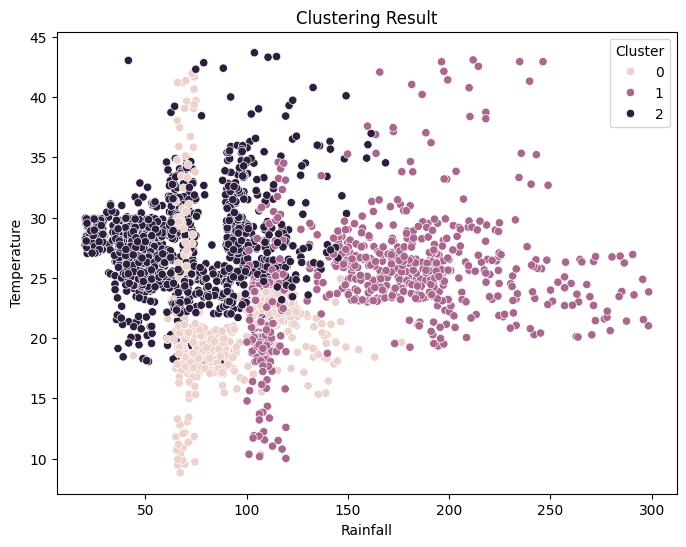

In [31]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=df["Rainfall"], y=df["Temperature"], hue=df["Cluster"])
plt.title("Clustering Result")
plt.show()